# Week 6: Generative Adversarial Networks (GANs)
### Author: Rajit Rajpal
The goal of this tutorial will be to learn about GANs, its associated problems in mode collapse and instability, and some variants offering solutions to said problems. `# TODO` are for you to implement. Solutions will contain the completed code.

### Imports

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import PIL.Image
from scipy.ndimage import gaussian_filter

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1 Mathematical Foundation
Generative Adversarial Networks (GANs) consist of two networks playing a minimax game.
![GAN Example](GANs.png)

**The Discriminator (D):** Tries to distinguish between real data and fake data.

**The Generator (G):** Tries to map a latent noise vector \( z \) to the data distribution to fool the Discriminator.

The original objective function is defined by the **binary cross-entropy**:

$$
\min_G \max_D \; V(D,G)
=
\mathbb{E}_{x \sim p_{\text{data}}(x)} \left[ \log D(x) \right]
+
\mathbb{E}_{z \sim p_z(z)} \left[ \log\big(1 - D(G(z))\big) \right]
$$


# 2 Setup and Data Loading

In [11]:
def plot_gan_state(G, D, real_samples, epoch, title):
    G.eval(); D.eval()
    with torch.no_grad():
        # Generate fake samples
        z = torch.randn(2000, 2)
        fake_samples = G(z).cpu().numpy()
        
        # Create a grid for Discriminator Heatmap
        x = np.linspace(-1.2, 1.2, 100)
        y = np.linspace(-1.2, 1.2, 100)
        X, Y = np.meshgrid(x, y)
        grid_tensor = torch.FloatTensor(np.c_[X.ravel(), Y.ravel()])
        Z = D(grid_tensor).reshape(X.shape).cpu().numpy()

    plt.figure(figsize=(8, 6))
    # Plot Discriminator Heatmap
    im = plt.imshow(Z, extent=[-1.2, 1.2, -1.2, 1.2], origin='lower', cmap='RdBu', alpha=0.5)
    plt.colorbar(im, label='D(x) Output')
    
    # Plot Real vs Fake
    plt.scatter(real_samples[:1000, 0], real_samples[:1000, 1], s=2, alpha=0.3, label='Real (Cat)', color='green')
    plt.scatter(fake_samples[:, 0], fake_samples[:, 1], s=2, alpha=0.5, label='Fake (Generated)', color='hotpink')
    
    plt.title(f"{title} - Epoch {epoch}")
    plt.legend()
    plt.show()

def get_cat_samples(n_samples=10000, sigma=2.0):
    try:
        # Load image and convert to grayscale
        cat = PIL.Image.open("cat.png").convert('L')
        arr = 1.0 - (np.array(cat) / 255.0) # Invert so cat is high density (1)
        
        # Apply Gaussian Blur to smooth the distribution
        smoothed_arr = gaussian_filter(arr, sigma=sigma)
        # Normalize to make it a valid probability map
        prob_map = smoothed_arr / smoothed_arr.sum()
    except FileNotFoundError:
        print("Cat image not found, using a fallback density.")
        # Fallback to a simple 2D Gaussian if file is missing
        return torch.randn(n_samples, 2) * 0.5

    # Rejection Sampling or Weighted Sampling
    flat_probs = prob_map.flatten()
    indices = np.random.choice(len(flat_probs), size=n_samples, p=flat_probs)
    
    # Convert 1D indices back to 2D coordinates
    rows, cols = np.unravel_index(indices, prob_map.shape)
    
    # Map to [-1, 1] range
    points = np.zeros((n_samples, 2))
    points[:, 0] = (cols / prob_map.shape[1]) * 2 - 1
    points[:, 1] = 1 - (rows / prob_map.shape[0]) * 2
    
    # Add a tiny bit of noise to prevent points from collapsing onto pixel grid
    points += np.random.normal(0, 0.01, points.shape)
    
    return torch.from_numpy(points).float()

cat_points = get_cat_samples(10000, sigma=3.0)

# 3 The Vanilla GAN: Instability and Mode Collapse
The "Standard" GAN uses a Sigmoid output and Binary Cross Entropy.

Issues:

**Vanishing Gradients**: If D gets too good, the gradient for G becomes zero.

**Mode Collapse**: The generator finds one "safe" spot (e.g., just the cat's ear) and puts all its probability mass there.

### 3.1 Architecture

In [12]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 2))
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, use_sigmoid=True):
        super().__init__()
        self.use_sigmoid = use_sigmoid
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1))
    def forward(self, x):
        out = self.net(x)
        return torch.sigmoid(out) if self.use_sigmoid else out

### 3.2 Gradient Penalties

#### 1. Vanilla GAN (Saturating vs. Non-Saturating)

The original GAN objective is based on a minimax game using the **Jensen–Shannon Divergence**.

##### The Minimax Objective
$$
\min_G \max_D \; V(D,G)
=
\mathbb{E}_{x\sim p_{\text{data}}}\big[\log D(x)\big]
+
\mathbb{E}_{z\sim p_z}\big[\log(1-D(G(z)))\big]
$$

**The Problem:**  
In the early stages of training, $G$ is very poor. $D$ can distinguish fakes with near 100% certainty, causing the gradient of  
$\log(1-D(G(z)))$ to **saturate** (flatten).

**The Solution (Non-Saturating Loss):**  
Instead of minimizing the probability that $D$ is correct, $G$ maximizes the probability that \$D$ is wrong:

$$
L_G = -\mathbb{E}_{z\sim p_z}\big[\log D(G(z))\big]
$$

---

#### 2. Least Squares GAN (LSGAN)

LSGAN replaces the **Binary Cross Entropy (BCE)** loss with **Mean Squared Error (MSE)**.

**Problem with BCE:**  
Once a fake sample is on the "correct" side of the decision boundary, the Vanilla GAN no longer strongly penalizes it. This can produce samples that still look fake.

**Solution:**  
MSE forces the Generator to push samples closer to the real data manifold by minimizing the distance to the real label (1).

##### Discriminator Loss
$$
\min_D \; \frac{1}{2}\mathbb{E}_{x\sim p_{\text{data}}}\big[(D(x)-1)^2\big]
+
\frac{1}{2}\mathbb{E}_{z\sim p_z}\big[D(G(z))^2\big]
$$

##### Generator Loss
$$
\min_G \; \frac{1}{2}\mathbb{E}_{z\sim p_z}\big[(D(G(z))-1)^2\big]
$$

---

#### 3. Wasserstein GAN with Gradient Penalty (WGAN-GP)

WGAN redefines the Discriminator as a **Critic** $f$, which outputs a scalar score rather than a probability.  
It estimates the **Wasserstein (Earth Mover’s) distance**.

##### Objective
$$
\min_G \max_{f\in\mathcal{D}}
\;
\mathbb{E}_{x\sim p_{\text{data}}}[f(x)]
-
\mathbb{E}_{z\sim p_z}[f(G(z))]
$$

##### Lipschitz Constraint
The critic must be **K-Lipschitz continuous**, meaning gradients cannot grow arbitrarily large.

##### Gradient Penalty
$$
\lambda
\mathbb{E}_{\hat{x}\sim p_{\hat{x}}}
\Big[
(\|\nabla_{\hat{x}} f(\hat{x})\|_2 - 1)^2
\Big]
$$

where $ \hat{x} $ is a random interpolation between real and fake samples.

---

#### 4. "Long Live the GAN": R1 Regularization

Modern architectures (e.g., StyleGAN) often use the **Non-Saturating loss** combined with an **R1 gradient penalty**.

**Idea:**  
Penalize the Discriminator gradients **only on real samples**, preventing sharp peaks around real data points and improving stability.

##### R1 Penalty
$$
R_1(\psi)
=
\frac{\gamma}{2}
\mathbb{E}_{x\sim p_{\text{data}}}
\Big[
\|\nabla D_\psi(x)\|_2^2
\Big]
$$

**Result:**  
Encourages flatter gradients on the real data manifold, making training more stable and reducing oscillations and mode collapse.


In [13]:
def compute_gradient_penalty(D, real_samples, fake_samples):
    """Calculates the gradient penalty for WGAN-GP."""
    alpha = torch.rand(real_samples.size(0), 1).to(device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = D(interpolates)
    fake = torch.ones(real_samples.size(0), 1).to(device)
    
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty * 10.0 # Lambda weight

def compute_r1_penalty(D, real_samples):
    """Calculates the R1 regularization penalty."""
    real_samples.requires_grad_(True)
    real_predict = D(real_samples)
    grad_real = torch.autograd.grad(
        outputs=real_predict.sum(), 
        inputs=real_samples, 
        create_graph=True
    )[0]
    # Penalize the squared norm of the gradients
    r1_loss = grad_real.pow(2).reshape(grad_real.shape[0], -1).sum(1).mean()
    return r1_loss * 10.0 # Gamma weight

### 3.3 Training

Starting training: r1-gan mode
Epoch 0 | D Loss: 1.4060 | G Loss: 0.6481


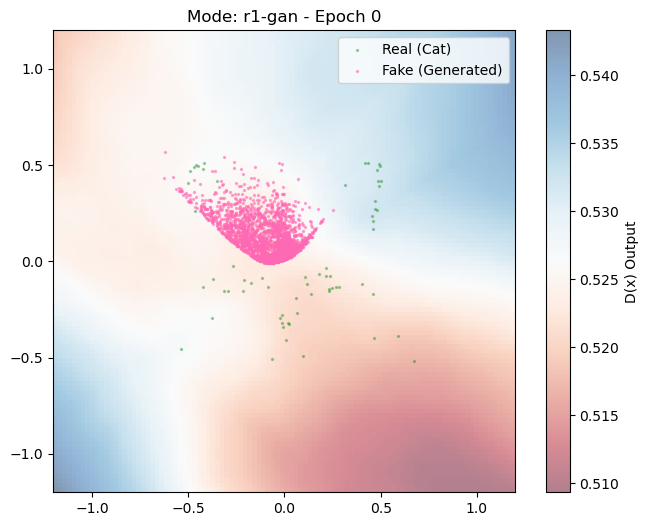

Epoch 1000 | D Loss: 1.3863 | G Loss: 0.6925


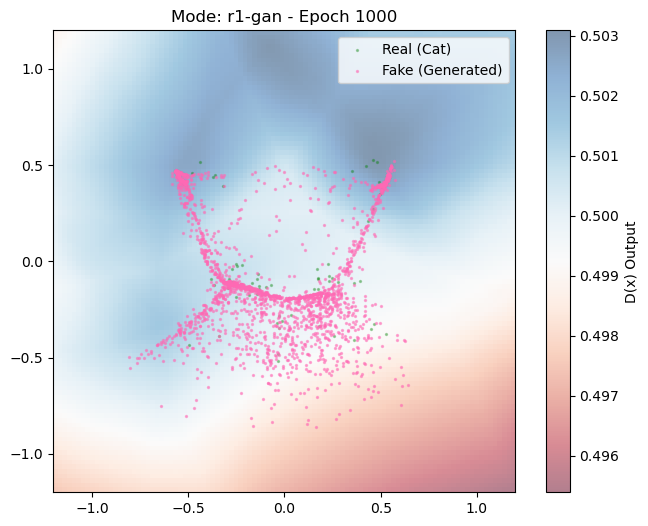

Epoch 2000 | D Loss: 1.3859 | G Loss: 0.6931


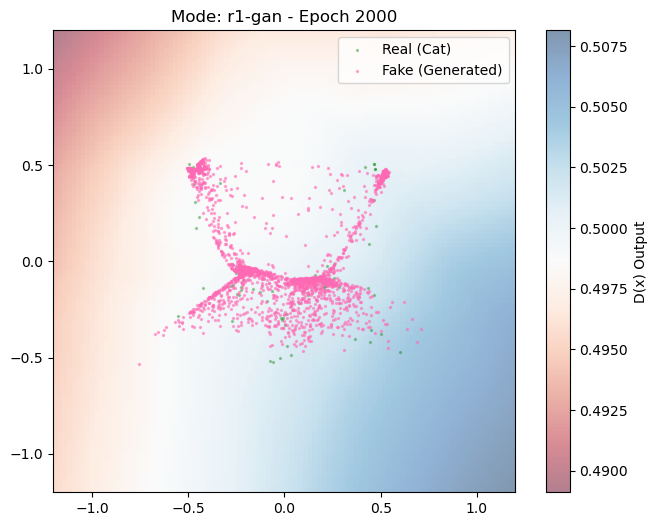

Epoch 3000 | D Loss: 1.3860 | G Loss: 0.6933


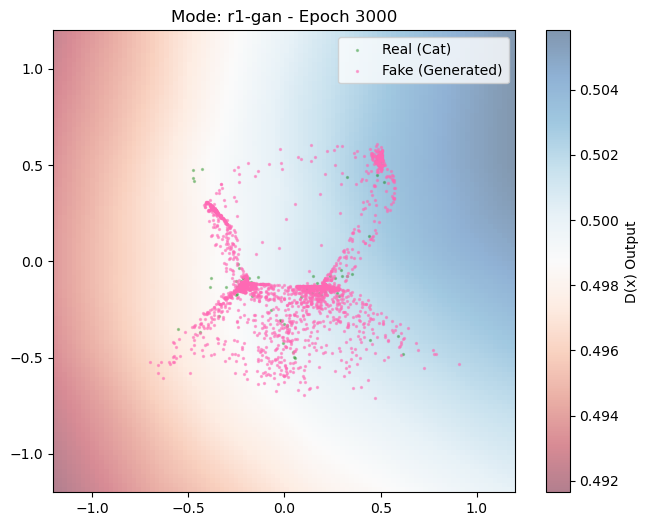

Epoch 4000 | D Loss: 1.3864 | G Loss: 0.6948


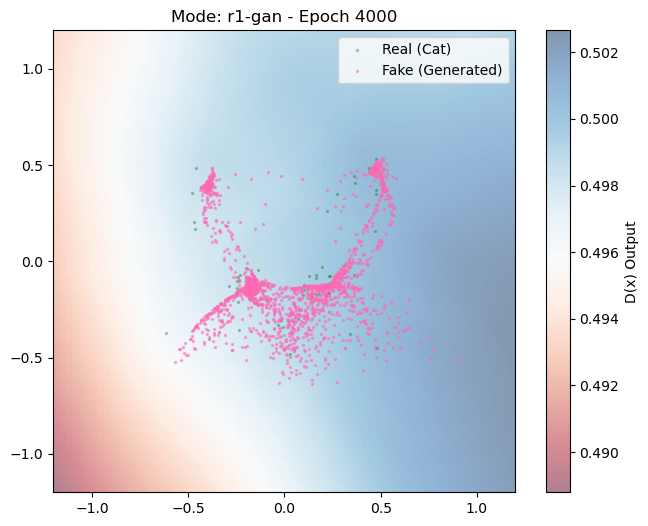

Epoch 5000 | D Loss: 1.3862 | G Loss: 0.6950


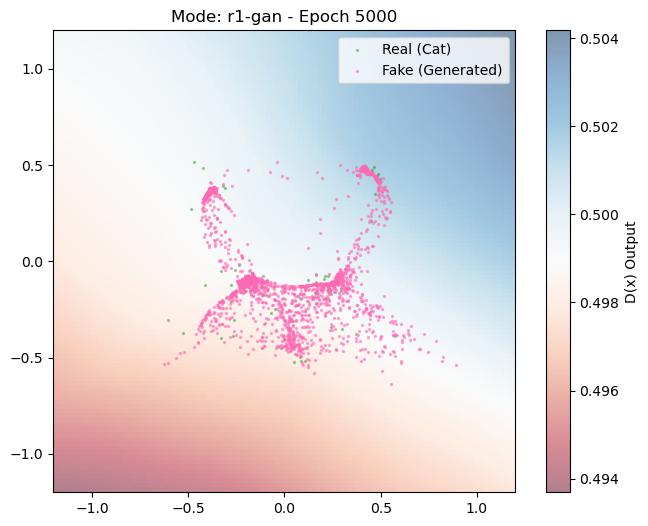

In [14]:
def train_gan(mode='vanilla', epochs=5000, lr=1e-3, batch_size=64):
    print(f"Starting training: {mode} mode")
    G = Generator().to(device)
    # R1 and Vanilla use Sigmoid; WGAN and LSGAN do not
    use_sig = True if mode in ['vanilla', 'r1-gan'] else False
    D = Discriminator(use_sigmoid=use_sig).to(device)
    
    optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9) if mode != 'vanilla' else (0.9, 0.999))
    optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.9) if mode != 'vanilla' else (0.9, 0.999))
    
    criterion = nn.BCELoss() if use_sig else nn.MSELoss()

    for epoch in range(epochs):
        # --- 1. Train Discriminator ---
        optimizer_D.zero_grad()
        real_data = get_cat_samples(batch_size).to(device)
        d_real = D(real_data)
        
        z = torch.randn(batch_size, 2).to(device)
        fake_data = G(z)
        d_fake = D(fake_data.detach())

        if mode == 'vanilla':
            loss_D = criterion(d_real, torch.ones_like(d_real)) + \
                     criterion(d_fake, torch.zeros_like(d_fake))
        elif mode == 'lsgan':
            loss_D = 0.5 * (torch.mean((d_real - 1)**2) + torch.mean(d_fake**2))
        elif mode == 'wgan-gp':
            gp = compute_gradient_penalty(D, real_data, fake_data.detach())
            loss_D = -torch.mean(d_real) + torch.mean(d_fake) + gp
        elif mode == 'r1-gan':
            # Binary Cross Entropy + R1 penalty on real data
            loss_D = criterion(d_real, torch.ones_like(d_real)) + \
                     criterion(d_fake, torch.zeros_like(d_fake))
            loss_D += compute_r1_penalty(D, real_data)
        
        loss_D.backward()
        optimizer_D.step()

        # --- 2. Train Generator ---
        optimizer_G.zero_grad()
        d_fake_for_g = D(fake_data)
        
        if mode in ['vanilla', 'r1-gan']:
            # Non-saturating loss (maximize log D(G(z)))
            loss_G = criterion(d_fake_for_g, torch.ones_like(d_fake_for_g))
        elif mode == 'lsgan':
            loss_G = 0.5 * torch.mean((d_fake_for_g - 1)**2)
        elif mode == 'wgan-gp':
            loss_G = -torch.mean(d_fake_for_g)

        loss_G.backward()
        optimizer_G.step()

        # Diagnostics
        if epoch % 1000 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")
            plot_gan_state(G, D, real_data.detach().cpu().numpy(), epoch, f"Mode: {mode}")

# Try the modern R1 variant!
train_gan(mode='r1-gan', epochs=5001)